# Application laboratory: $K$-SAT as a hard-factor graphical model

A $K$-SAT instance is a product of hard clause factors. For Boolean variables $x_i\in\{0,1\}$, each clause is one when at least one of its literals is satisfied and zero otherwise. The partition function

$$
Z=\sum_x \prod_A f_A(x_A)
$$

is therefore the number of satisfying assignments. The same graphical model supports feasibility, counting, marginal inference over satisfying assignments, and zero-temperature optimization.

In [1]:
CHAPTER_DIR="ch11"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / CHAPTER_DIR).exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

def save_figure(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    print("Saved", stem)

def draw_dark_nodes(G, pos, labels=None, ax=None, node_size=1200, arrows=False, **kwargs):
    if ax is None: ax=plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#303030", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)
    return ax

def annotate_heatmap(ax, image, values, fmt=".2f"):
    arr=np.asarray(values)
    lo,hi=np.nanmin(arr),np.nanmax(arr)
    mid=(lo+hi)/2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color="white" if arr[i,j] < mid else "black"
            ax.text(j,i,format(arr[i,j],fmt),ha="center",va="center",color=color,fontsize=11)

In [2]:
from itertools import product
n=8
# Each clause is a list of (variable index, satisfying value).
clauses=[[(0,1),(1,0),(3,1)],[(1,1),(2,1),(4,0)],[(0,0),(4,1),(5,1)],
         [(2,0),(3,0),(6,1)],[(1,0),(5,0),(7,1)],[(0,1),(6,0),(7,0)],
         [(2,1),(4,1),(7,1)],[(3,1),(5,1),(6,0)],[(0,0),(2,0),(5,1)],[(1,1),(6,1),(7,0)]]
states=np.array(list(product([0,1],repeat=n)),dtype=int)
def clause_sat(x,c): return any(x[i]==val for i,val in c)
sat_matrix=np.array([[clause_sat(x,c) for c in clauses] for x in states])
num_sat=sat_matrix.sum(axis=1)
solutions=states[num_sat==len(clauses)]
print('satisfying assignments Z =',len(solutions))
assert len(solutions)>0
marg=solutions.mean(axis=0)

satisfying assignments Z = 50


/tmp/ipykernel_2036/1440664098.py:38: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)


Saved ch11_03_ksat_factor_graph


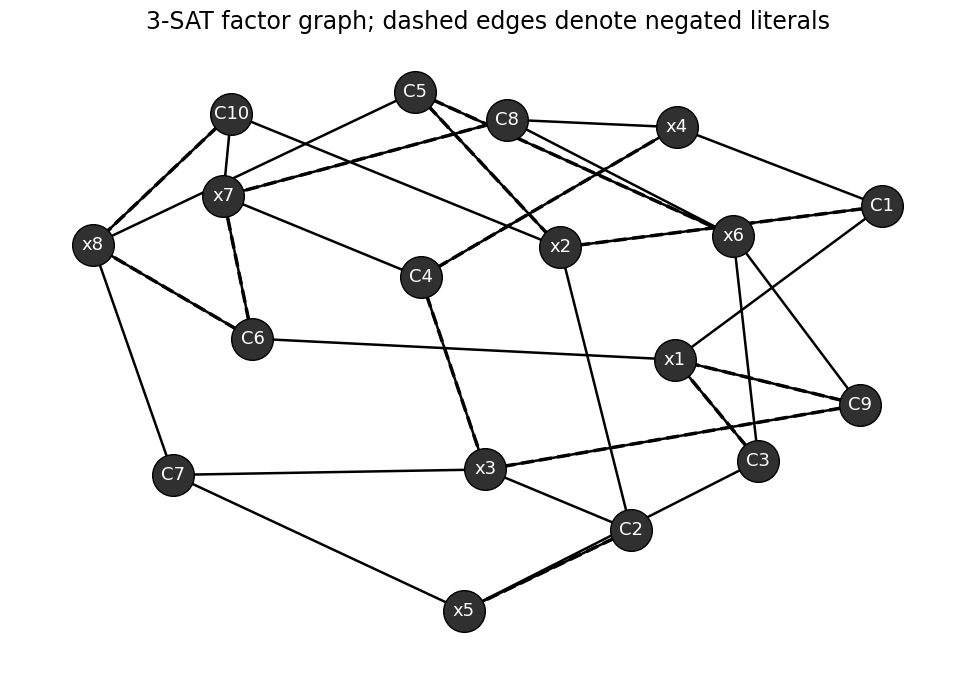

Saved ch11_03_ksat_solution_statistics


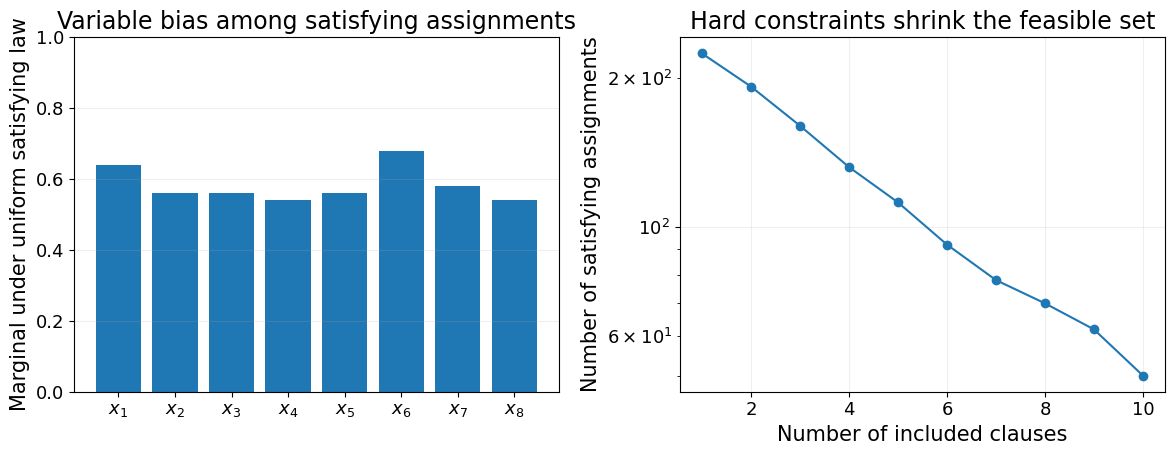

In [3]:
G=nx.Graph(); vnodes=[f'x{i+1}' for i in range(n)]; cnodes=[f'C{a+1}' for a in range(len(clauses))]
G.add_nodes_from(vnodes); G.add_nodes_from(cnodes)
for a,c in enumerate(clauses):
    for i,val in c: G.add_edge(cnodes[a],vnodes[i])
pos=nx.spring_layout(G,seed=2,k=.7)
fig,ax=plt.subplots(figsize=(10,7)); draw_dark_nodes(G,pos,labels={u:u for u in G},ax=ax,node_size=900)
# mark negated literal edges by dashed overlay
for a,c in enumerate(clauses):
    for i,val in c:
        if val==0: nx.draw_networkx_edges(G,pos,edgelist=[(cnodes[a],vnodes[i])],style='dashed',width=2.5,ax=ax)
ax.set_title("3-SAT factor graph; dashed edges denote negated literals"); ax.axis('off'); fig.tight_layout(); save_figure(fig,'ch11_03_ksat_factor_graph'); plt.show()

counts=[np.sum(sat_matrix[:,:m].all(axis=1)) for m in range(1,len(clauses)+1)]
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
axes[0].bar(np.arange(n),marg); axes[0].set_xticks(range(n),[rf'$x_{i+1}$' for i in range(n)]); axes[0].set_ylim(0,1); axes[0].set_ylabel('Marginal under uniform satisfying law'); axes[0].set_title('Variable bias among satisfying assignments'); axes[0].grid(axis='y',alpha=.2)
axes[1].plot(range(1,len(clauses)+1),counts,marker='o'); axes[1].set_yscale('log'); axes[1].set_xlabel('Number of included clauses'); axes[1].set_ylabel('Number of satisfying assignments'); axes[1].set_title('Hard constraints shrink the feasible set'); axes[1].grid(alpha=.2)
fig.tight_layout(); save_figure(fig,'ch11_03_ksat_solution_statistics'); plt.show()

## Exercises

1. Add clauses one at a time until the instance becomes unsatisfiable. Which observable signals the transition first: $Z$, a variable marginal, or the number of nearly satisfied assignments?
2. Replace the hard clause factor by $f_A=\exp(-\beta\,\mathbf 1[\text{clause violated}])$. Study the transition from soft inference to SAT as $\beta$ grows.
3. Run loopy BP on this factor graph and compare its variable marginals with the exact uniform-solution marginals.
4. Treat the number of violated clauses as an energy and compare local search, MAP-LP, and simulated annealing.